!pip3 install git+https://github.com/NetManAIOps/sktime.git

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler

In [33]:
# Reproducible synthetic MTS with clearer differences across 6 dimensions
rng = np.random.default_rng(42)
n_timestamps = 300
t = np.arange(n_timestamps)

# Two periodic elements, with channel-specific phase shift
phase1 = np.array([0, 2, 5, 8, 11, 14])
phase2 = np.array([0, 4, 9, 13, 18, 22])

s1_bank = np.sin(2 * np.pi * (t[:, None] + phase1) / 24) + 0.20 * np.sin(2 * np.pi * (t[:, None] + phase1) / 6)
s2_bank = np.cos(2 * np.pi * (t[:, None] + phase2) / 60) + 0.15 * np.cos(2 * np.pi * (t[:, None] + phase2) / 10)

# Different weights + tiny trend/offset per channel
w1 = np.array([1.2, 0.8, 1.4, 0.5, 1.1, 0.7])
w2 = np.array([0.3, -0.6, 0.9, 1.1, -1.0, 0.4])
trend = np.array([0.10, -0.08, 0.05, 0.12, -0.10, 0.07])
offset = np.array([0.2, -0.3, 0.1, 0.5, -0.4, 0.0])

noise = 0.06 * rng.normal(size=(n_timestamps, 6))
X = w1 * s1_bank + w2 * s2_bank + trend * (t[:, None] / n_timestamps) + offset + noise
X.shape

(300, 6)

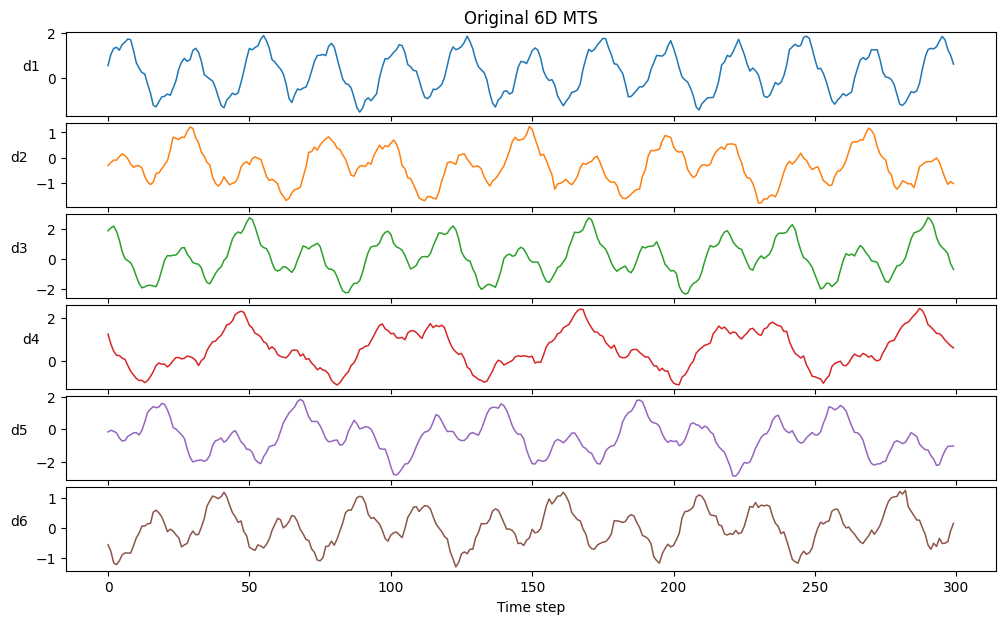

In [34]:
# Before reduction: show each dimension separately (compact 6x1)
dim_colors = plt.cm.tab10(np.arange(6))
fig, axes = plt.subplots(6, 1, figsize=(12, 7), sharex=True)
for i in range(6):
    axes[i].plot(t, X[:, i], color=dim_colors[i], linewidth=1.1)
    axes[i].set_ylabel(f"d{i+1}", rotation=0, labelpad=12)
axes[0].set_title("Original 6D MTS")
axes[-1].set_xlabel("Time step")
fig.subplots_adjust(hspace=0.08)
plt.show()

In [35]:
# Standardize, reduce to 2D, then reconstruct back to 6D
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca_rec = scaler.inverse_transform(pca.inverse_transform(X_pca))

ica = FastICA(n_components=2, random_state=42, max_iter=2000)
X_ica = ica.fit_transform(X_scaled)
X_ica_rec = scaler.inverse_transform(ica.inverse_transform(X_ica))

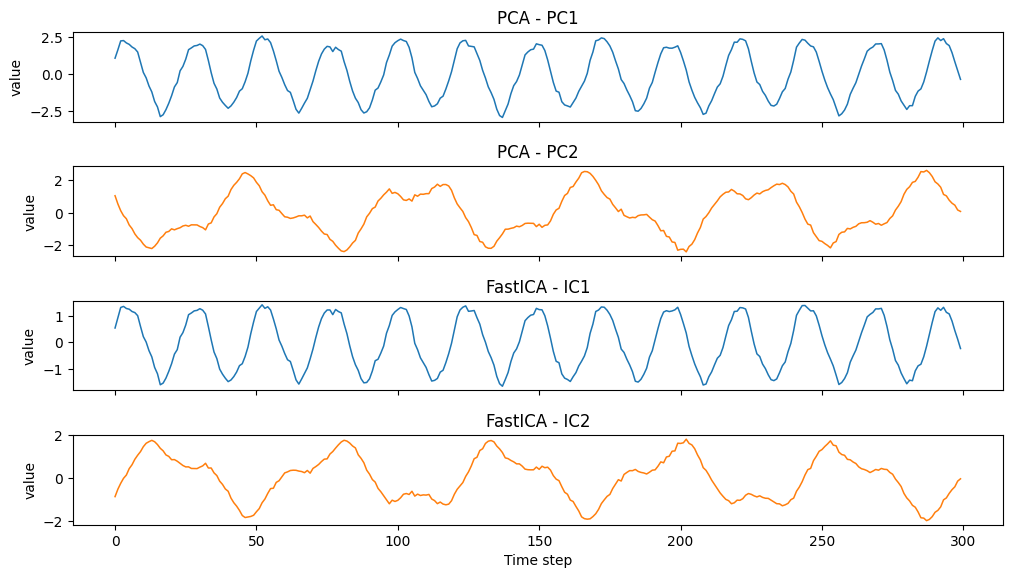

In [37]:
# 2D reduced results: PCA vs FastICA
fig, axes = plt.subplots(4, 1, figsize=(12, 6.4), sharex=True)

axes[0].plot(t, X_pca[:, 0], color="tab:blue", linewidth=1.1)
axes[0].set_title("PCA - PC1")
axes[0].set_ylabel("value")

axes[1].plot(t, X_pca[:, 1], color="tab:orange", linewidth=1.1)
axes[1].set_title("PCA - PC2")
axes[1].set_ylabel("value")

axes[2].plot(t, X_ica[:, 0], color="tab:blue", linewidth=1.1)
axes[2].set_title("FastICA - IC1")
axes[2].set_ylabel("value")

axes[3].plot(t, X_ica[:, 1], color="tab:orange", linewidth=1.1)
axes[3].set_title("FastICA - IC2")
axes[3].set_ylabel("value")
axes[3].set_xlabel("Time step")

fig.subplots_adjust(hspace=0.5)
plt.show()

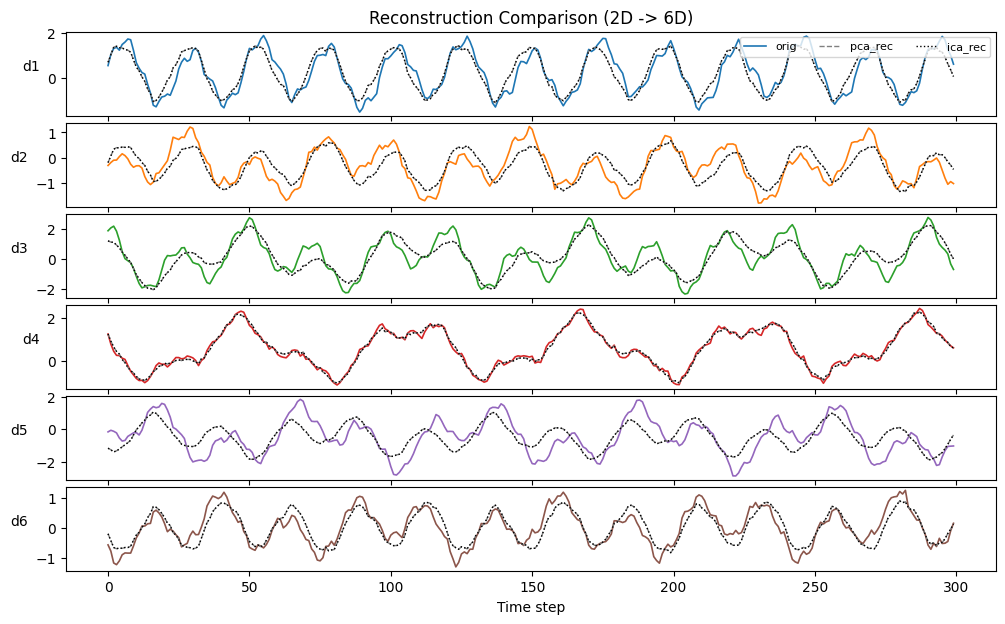

In [31]:
# Reconstruction comparison in one figure: orig vs PCA vs FastICA (6x1)
fig, axes = plt.subplots(6, 1, figsize=(12, 7), sharex=True)
for i in range(6):
    c = dim_colors[i]
    axes[i].plot(t, X[:, i], color=c, linewidth=1.2, linestyle="-", label="orig")
    axes[i].plot(t, X_pca_rec[:, i], color='grey', linewidth=1.0, linestyle="--", label="pca_rec")
    axes[i].plot(t, X_ica_rec[:, i], color='black', linewidth=1.0, linestyle=":", label="ica_rec")
    axes[i].set_ylabel(f"d{i+1}", rotation=0, labelpad=12)
axes[0].set_title("Reconstruction Comparison (2D -> 6D)")
axes[0].legend(loc="upper right", ncol=3, fontsize=8)
axes[-1].set_xlabel("Time step")
fig.subplots_adjust(hspace=0.08)
plt.show()